First 5 loss:
18.885013890337703
18.8822755144984
18.86358826449383
18.84986439253935
18.827920166736323

Last 5 loss:
2.673197217271332
2.6687320195562023
2.6642813201700632
2.659842228662758
2.6554100284523585


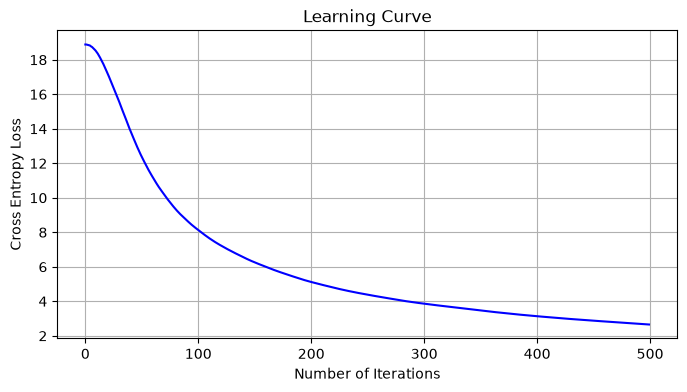

Test Accuracy: 81.71%


In [1]:
import numpy as np
import pandas as pd
from sklearn.preprocessing import OneHotEncoder
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
plt.style.use('default')
import os


class DenseLayer:
    def __init__(self, n_in, n_out):
        self.n_in = n_in
        self.n_out = n_out
        self.weight = np.random.randn(n_in, n_out)
        self.bias = np.zeros((1, n_out))

    def forward(self, x):
        self.input = x
        z = x @ self.weight + self.bias

        #print(f"[DenseLayer.forward] input {x.shape} -> output {z.shape}")
        return z

    def backward(self, grad_output):
        self.grad_op = grad_output

        self.dW = np.transpose(self.input) @ self.grad_op
        self.db = np.sum(self.grad_op, axis=0, keepdims=True)

        derivativex = self.grad_op @ np.transpose(self.weight)

        #print(f"[DenseLayer.backward] grad_in {grad_output.shape} -> dW {self.dW.shape}, db {self.db.shape}, grad_out {derivativex.shape}")
        return derivativex

#//////////////////////////////////////////////////////////////////////////

class ReLu:
    def forward(self, x):
        self.mask = (x > 0)

        out = np.maximum(0, x)
        #print(f"[ReLu.forward] input {x.shape} -> output {out.shape}")
        return np.maximum(0, x)

    def backward(self, grad_output):
        self.grad_op = grad_output
        dl_dz = self.grad_op * self.mask

        #print(f"[ReLu.backward] grad_in {grad_output.shape} -> grad_out {dl_dz.shape}")
        return dl_dz
        
#//////////////////////////////////////////////////////////////////////////

class Softmax:
    def forward(self, x):
        self.input = x
        shifted = x - np.max(x, axis=1, keepdims=True)
        exp_values = np.exp(shifted)
        probs = exp_values / np.sum(exp_values, axis=1, keepdims=True)

        #print(f"[Softmax.forward] input {x.shape} -> output {probs.shape}")
        return probs

#//////////////////////////////////////////////////////////////////////////

class CrossEntropyLoss:
    def forward(self,predictions, targets):
        self.predictions = predictions
        self.targets = targets
        value1 = -np.sum(targets * np.log(predictions + 1e-9), axis=1, keepdims=True)
        loss = np.mean(value1)

        #print(f"[CrossEntropyLoss.forward] loss = {loss:.4f}")
        return loss

    def backward(self):
        grad_output = self.predictions - self.targets

        #print(f"[CrossEntropyLoss.backward] grad_out {grad_output.shape}")
        return grad_output

#//////////////////////////////////////////////////////////////////////////

class Network:
    def __init__(self, layers: list):
        self.layers = layers

    def forward(self, x):
        #print("[Network.forward] started")

        for layer in self.layers:
            x = layer.forward(x)

        #print("[Network.forward] finished")
        return x

    def backward(self, grad):
        #print("[Network.backward] started")


        for layer in reversed(self.layers):
            grad = layer.backward(grad)

        #print("[Network.backward] finished")
        return grad

#//////////////////////////////////////////////////////////////////////////

class AdamOptimizer:
    def __init__(self, layers, lr=0.001, beta1=0.9, beta2=0.999, epsilon=1e-8):
        self.layers = layers
        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2
        self.epsilon = epsilon
        self.t = 0

        for layer in self.layers:
            layer.m_w = np.zeros_like(layer.weight)
            layer.v_w = np.zeros_like(layer.weight)
            layer.m_b = np.zeros_like(layer.bias)
            layer.v_b = np.zeros_like(layer.bias)

    def step(self):
        self.t += 1

        for layer in self.layers:
            layer.m_w = self.beta1 * layer.m_w + (1 - self.beta1) * layer.dW
            layer.v_w = self.beta2 * layer.v_w + (1 - self.beta2) * (layer.dW ** 2)

            m_hat_w = layer.m_w / (1 - self.beta1 ** self.t)
            v_hat_w = layer.v_w / (1 - self.beta2 ** self.t)

            layer.weight -= self.lr * m_hat_w / (np.sqrt(v_hat_w) + self.epsilon)

            #--------------------------------------------------------------------------
            
            layer.m_b = self.beta1 * layer.m_b + (1 - self.beta1) * layer.db
            layer.v_b = self.beta2 * layer.v_b + (1 - self.beta2) * (layer.db ** 2)

            m_hat_b = layer.m_b / (1 - self.beta1 ** self.t)
            v_hat_b = layer.v_b / (1 - self.beta2 ** self.t)

            layer.bias -= self.lr * m_hat_b / (np.sqrt(v_hat_b) + self.epsilon)

#//////////////////////////////////////////////////////////////////////////

#--------------------DATA--------------------
data_set = pd.read_csv('train.csv')
x = data_set.drop('label', axis=1).values 
y = data_set['label'].values

encoder = OneHotEncoder(sparse_output=False)
targets = encoder.fit_transform(y.reshape(-1, 1))

x_train, x_val, y_train, y_val = train_test_split(x, targets, test_size=0.1, random_state=42)
x_train = x_train / 255.0
x_val = x_val / 255.0
true_classes = np.argmax(y_val, axis=1)

#--------------------OBJECTS--------------------
layer1 = DenseLayer(784, 128)
relu1 = ReLu()
layer2 = DenseLayer(128, 64)
relu2 = ReLu()
layer3 = DenseLayer(64, 10)

loss_history = []

#--------------------NETWORK--------------------
net = Network([layer1, relu1, layer2, relu2, layer3])
somax = Softmax()
celoss = CrossEntropyLoss()
optimizer = AdamOptimizer([layer1, layer2, layer3], lr=0.001)

n_iterations = 500

#--------------------TRAINING--------------------
for iteration in range(n_iterations):
    z = net.forward(x_train)
    predictions = somax.forward(z)
    loss = celoss.forward(predictions, y_train)
    loss_history.append(loss)

    grad = celoss.backward()
    net.backward(grad)
    optimizer.step()

#--------------------TEST--------------------
z_val = net.forward(x_val)
predictions_val = somax.forward(z_val)
predicted_classes = np.argmax(predictions_val, axis=1)

#--------------------RESULTS--------------------
print("First 5 loss:")
for l in loss_history[:5]:
    print(l)

print("\nLast 5 loss:")
for l in loss_history[-5:]:
    print(l)


plt.figure(figsize=(8, 4))
plt.plot(range(len(loss_history)), loss_history, "b-")
plt.title("Learning Curve")
plt.xlabel("Number of Iterations")
plt.ylabel("Cross Entropy Loss")
plt.grid(True)
plt.show()


test_accuracy = accuracy_score(true_classes, predicted_classes)
print(f"Test Accuracy: {test_accuracy*100:.2f}%")
